# Notebook 08 — Segmented Data Preparation

## Objective
Prepare a new dataset using segmentation masks to isolate upper and lower garment regions,
enabling two separate models to classify each region independently.

## Approach
For each image with a segmentation mask:
- Extract the **upper region** (top, outer) → used to train the upper model
- Extract the **lower region** (pants, skirt, dress, leggings) → used to train the lower model

## New Tasks
| Model | Tasks |
|---|---|
| Upper | sleeve_length (4 classes), upper_fabric (7 classes), upper_color (7 classes) |
| Lower | lower_fabric (7 classes), lower_length (4 classes) |

## Inputs
- `train.csv`, `val.csv`, `test.csv` — original splits (Notebook 02)
- Segmentation masks — 12,701 full body images
- Shape and fabric annotations — DeepFashion-MultiModal labels

# 1 — Imports & Environment Check

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

print("Imports done.")
print(f"PIL version: {Image.__version__}")

Imports done.
PIL version: 11.3.0


# 2 — Paths & Label Mappings

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
IMAGE_DIR  = Path("/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/images/images")
SEGM_DIR   = Path("/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/segm/segm")
LABELS_DIR = Path("/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/labels/labels")
NB02_DIR   = Path("/kaggle/input/notebooks/miguelmirandar/02-data-preparation")
OUT_DIR    = Path("/kaggle/working")

# ── Segmentation label groups ─────────────────────────────────────────────────
UPPER_LABELS = [1, 2]        # top, outer
LOWER_LABELS = [3, 4, 5, 6]  # skirt, dress, pants, leggings

# ── Task label maps ───────────────────────────────────────────────────────────
SLEEVE_MAP  = {0:"sleeveless", 1:"short", 2:"medium", 3:"long"}
FABRIC_MAP  = {0:"denim", 1:"cotton", 2:"leather", 3:"furry", 4:"knitted", 5:"chiffon", 6:"other"}
COLOR_MAP   = {0:"floral", 1:"graphic", 2:"striped", 3:"pure color", 4:"lattice", 5:"other", 6:"color block"}
LOWER_LENGTH_MAP = {0:"three-point", 1:"medium short", 2:"three-quarter", 3:"long"}

# ── NA values to exclude ──────────────────────────────────────────────────────
NA_VALUES = {
    "sleeve_length": [4, 5],
    "upper_fabric":  [7],
    "upper_color":   [7],
    "lower_fabric":  [7],
    "lower_length":  [4],
}

print("Paths and mappings defined.")
print(f"IMAGE_DIR exists : {IMAGE_DIR.exists()}")
print(f"SEGM_DIR exists  : {SEGM_DIR.exists()}")
print(f"LABELS_DIR exists: {LABELS_DIR.exists()}")

Paths and mappings defined.
IMAGE_DIR exists : True
SEGM_DIR exists  : True
LABELS_DIR exists: True


# 3 — Load & Merge All Annotations

In [3]:
# ── Shape annotations ─────────────────────────────────────────────────────────
shape_df = pd.read_csv(LABELS_DIR / "shape/shape_anno_all.txt",
                        sep=" ", header=None,
                        names=["image_name", "sleeve_length", "lower_length",
                               "socks", "hat", "glasses", "neckwear",
                               "wrist", "ring", "waist", "neckline",
                               "outer_cardigan", "upper_navel"])

# ── Fabric annotations ────────────────────────────────────────────────────────
fabric_df = pd.read_csv(LABELS_DIR / "texture/fabric_ann.txt",
                         sep=" ", header=None,
                         names=["image_name", "upper_fabric", "lower_fabric", "outer_fabric"])

# ── Pattern annotations ───────────────────────────────────────────────────────
pattern_df = pd.read_csv(LABELS_DIR / "texture/pattern_ann.txt",
                          sep=" ", header=None,
                          names=["image_name", "upper_color", "lower_color", "outer_color"])

# ── Merge all ─────────────────────────────────────────────────────────────────
df = shape_df[["image_name", "sleeve_length", "lower_length"]]\
     .merge(fabric_df[["image_name", "upper_fabric", "lower_fabric"]], on="image_name")\
     .merge(pattern_df[["image_name", "upper_color"]], on="image_name")

print(f"Total merged samples: {len(df):,}")
print(df.head(3))

Total merged samples: 42,544
                                  image_name  sleeve_length  lower_length  \
0  MEN-Denim-id_00000080-01_7_additional.jpg              5             3   
1  MEN-Denim-id_00000089-01_7_additional.jpg              0             3   
2  MEN-Denim-id_00000089-02_7_additional.jpg              3             3   

   upper_fabric  lower_fabric  upper_color  
0             1             1            3  
1             1             1            3  
2             1             1            2  


# 4 — Filter & Add Segmentation

In [4]:
# ── Remove NA values ──────────────────────────────────────────────────────────
for col, na_vals in NA_VALUES.items():
    df = df[~df[col].isin(na_vals)].reset_index(drop=True)

print(f"After NA filtering: {len(df):,}")

# ── Check segmentation availability ──────────────────────────────────────────
segm_files = set(os.listdir(SEGM_DIR))
df["segm_name"] = df["image_name"].apply(lambda x: Path(x).stem + "_segm.png")
df["has_segm"]  = df["segm_name"].isin(segm_files)

print(f"With segmentation : {df['has_segm'].sum():,}")

# ── Keep only samples with segmentation ──────────────────────────────────────
df_segm = df[df["has_segm"]].reset_index(drop=True)
print(f"Final dataset size: {len(df_segm):,}")

print(f"\nClass distributions:")
for col in ["sleeve_length", "upper_fabric", "lower_fabric", "lower_length"]:
    print(f"\n{col}:")
    print(df_segm[col].value_counts().sort_index())

After NA filtering: 25,093
With segmentation : 12,492
Final dataset size: 12,492

Class distributions:

sleeve_length:
sleeve_length
0    5262
1    2457
2     731
3    4042
Name: count, dtype: int64

upper_fabric:
upper_fabric
0      139
1    10274
2       16
3       29
4      561
5     1452
6       21
Name: count, dtype: int64

lower_fabric:
lower_fabric
0    4645
1    6368
2     491
3       2
4      52
5     906
6      28
Name: count, dtype: int64

lower_length:
lower_length
0    4728
1    1008
2     527
3    6229
Name: count, dtype: int64


# 5 — Train/Val/Test Split

In [5]:
from sklearn.model_selection import train_test_split

# ── Use sleeve_length as stratification key ───────────────────────────────────
train_df, temp_df = train_test_split(
    df_segm, test_size=0.30,
    stratify=df_segm["sleeve_length"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df["sleeve_length"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}")
print(f"Test  : {len(test_df):,}")

# ── Save splits ───────────────────────────────────────────────────────────────
train_df.to_csv(OUT_DIR / "train_segm.csv", index=False)
val_df.to_csv(OUT_DIR   / "val_segm.csv",   index=False)
test_df.to_csv(OUT_DIR  / "test_segm.csv",  index=False)

print("\nSaved: train_segm.csv, val_segm.csv, test_segm.csv")

Train : 8,744
Val   : 1,874
Test  : 1,874

Saved: train_segm.csv, val_segm.csv, test_segm.csv


# 6 — Crop & Save Segmented Regions

In [6]:
def get_crop(image, mask, labels, background="white"):
    """Crop the bounding box of the region defined by labels in the mask."""
    region_mask = np.isin(mask, labels)
    
    if not region_mask.any():
        return None
    
    # Bounding box
    rows = np.any(region_mask, axis=1)
    cols = np.any(region_mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Apply mask
    cropped = image.copy()
    if background == "white":
        cropped[~region_mask] = 255
    else:
        cropped[~region_mask] = 0

    return Image.fromarray(cropped[rmin:rmax+1, cmin:cmax+1])


def save_crops(df, split_name):
    """Save upper and lower crops for all images in a split."""
    upper_dir = OUT_DIR / f"crops/{split_name}/upper"
    lower_dir = OUT_DIR / f"crops/{split_name}/lower"
    upper_dir.mkdir(parents=True, exist_ok=True)
    lower_dir.mkdir(parents=True, exist_ok=True)

    missing_upper = 0
    missing_lower = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=split_name):
        img_path  = IMAGE_DIR / row["image_name"]
        segm_path = SEGM_DIR  / row["segm_name"]

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(segm_path))

        stem = Path(row["image_name"]).stem

        upper_crop = get_crop(image, mask, UPPER_LABELS)
        lower_crop = get_crop(image, mask, LOWER_LABELS)

        if upper_crop is not None:
            upper_crop.save(upper_dir / f"{stem}.jpg")
        else:
            missing_upper += 1

        if lower_crop is not None:
            lower_crop.save(lower_dir / f"{stem}.jpg")
        else:
            missing_lower += 1

    print(f"{split_name} — missing upper: {missing_upper} | missing lower: {missing_lower}")


save_crops(train_df, "train")
save_crops(val_df,   "val")
save_crops(test_df,  "test")

print("\nAll crops saved.")

train:   0%|          | 0/8744 [00:00<?, ?it/s]

train — missing upper: 2095 | missing lower: 531


val:   0%|          | 0/1874 [00:00<?, ?it/s]

val — missing upper: 451 | missing lower: 129


test:   0%|          | 0/1874 [00:00<?, ?it/s]

test — missing upper: 470 | missing lower: 146

All crops saved.


# 7 — Filter Missing Crops & Save Final CSVs

In [7]:
def filter_missing(df, split_name):
    """Remove rows where upper or lower crop is missing."""
    upper_dir = OUT_DIR / f"crops/{split_name}/upper"
    lower_dir = OUT_DIR / f"crops/{split_name}/lower"

    def has_upper(row):
        stem = Path(row["image_name"]).stem
        return (upper_dir / f"{stem}.jpg").exists()

    def has_lower(row):
        stem = Path(row["image_name"]).stem
        return (lower_dir / f"{stem}.jpg").exists()

    df = df.copy()
    df["has_upper_crop"] = df.apply(has_upper, axis=1)
    df["has_lower_crop"] = df.apply(has_lower, axis=1)

    df_upper = df[df["has_upper_crop"]].drop(columns=["has_upper_crop", "has_lower_crop"])
    df_lower = df[df["has_lower_crop"]].drop(columns=["has_upper_crop", "has_lower_crop"])

    return df_upper.reset_index(drop=True), df_lower.reset_index(drop=True)


train_upper, train_lower = filter_missing(train_df, "train")
val_upper,   val_lower   = filter_missing(val_df,   "val")
test_upper,  test_lower  = filter_missing(test_df,  "test")

# ── Save ──────────────────────────────────────────────────────────────────────
train_upper.to_csv(OUT_DIR / "train_upper.csv", index=False)
val_upper.to_csv(OUT_DIR   / "val_upper.csv",   index=False)
test_upper.to_csv(OUT_DIR  / "test_upper.csv",  index=False)

train_lower.to_csv(OUT_DIR / "train_lower.csv", index=False)
val_lower.to_csv(OUT_DIR   / "val_lower.csv",   index=False)
test_lower.to_csv(OUT_DIR  / "test_lower.csv",  index=False)

print("Upper model splits:")
print(f"  Train: {len(train_upper):,} | Val: {len(val_upper):,} | Test: {len(test_upper):,}")
print("\nLower model splits:")
print(f"  Train: {len(train_lower):,} | Val: {len(val_lower):,} | Test: {len(test_lower):,}")

Upper model splits:
  Train: 6,649 | Val: 1,423 | Test: 1,404

Lower model splits:
  Train: 8,213 | Val: 1,745 | Test: 1,728


# 8 — Visual Check

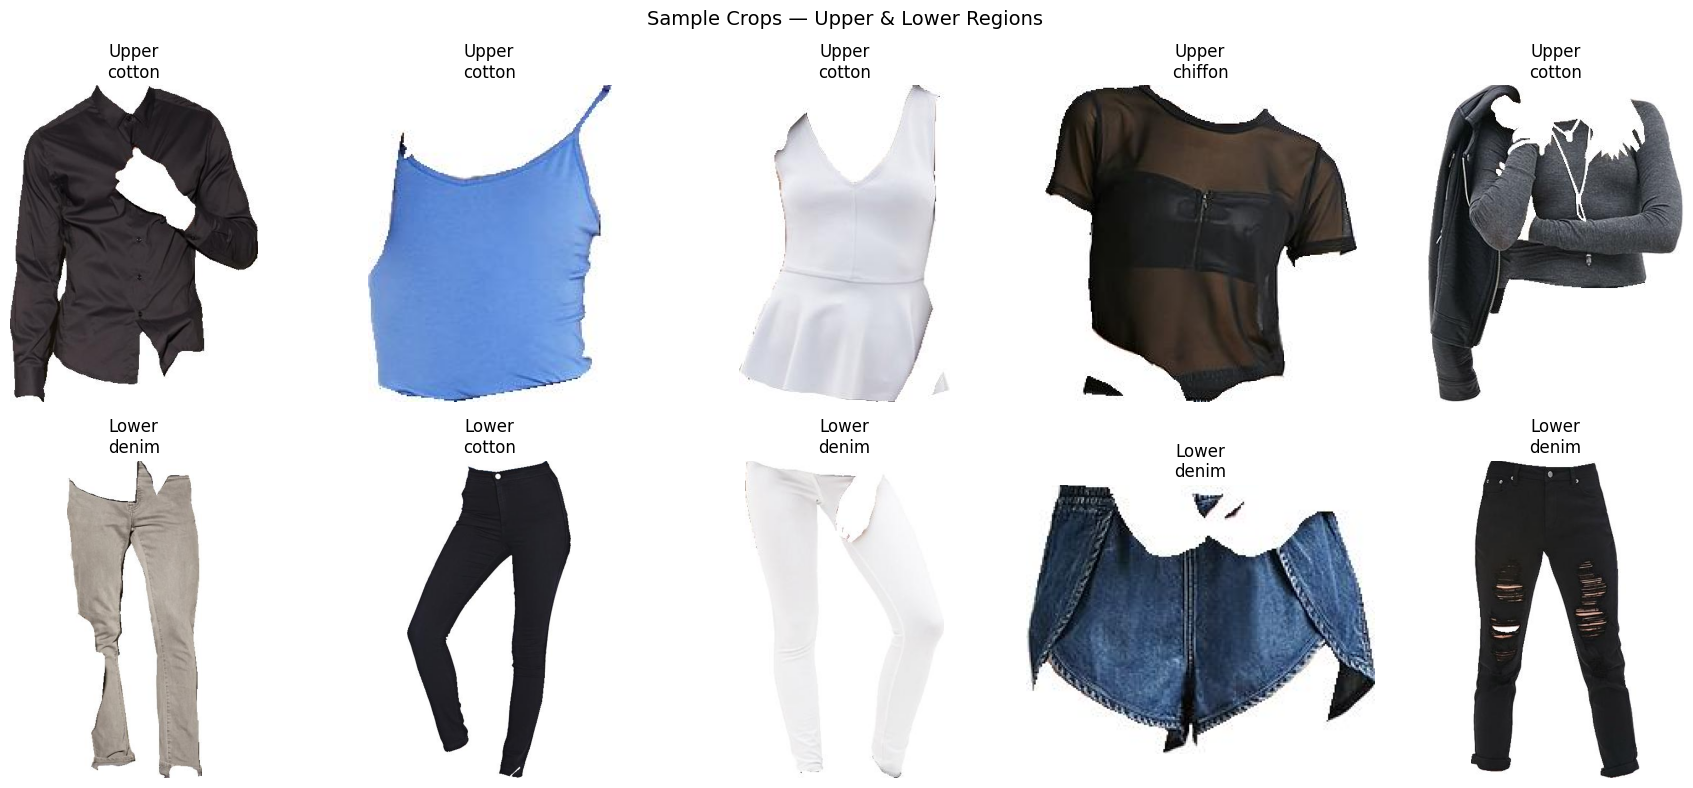

Saved: sample_crops.png


In [8]:
import random

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

samples = random.sample(range(len(train_upper)), 5)

for i, idx in enumerate(samples):
    row       = train_upper.iloc[idx]
    stem      = Path(row["image_name"]).stem
    upper_img = Image.open(OUT_DIR / f"crops/train/upper/{stem}.jpg")
    lower_img = Image.open(OUT_DIR / f"crops/train/lower/{stem}.jpg") \
                if (OUT_DIR / f"crops/train/lower/{stem}.jpg").exists() else None

    axes[0][i].imshow(upper_img)
    axes[0][i].set_title(f"Upper\n{FABRIC_MAP[row['upper_fabric']]}")
    axes[0][i].axis("off")

    if lower_img:
        axes[1][i].imshow(lower_img)
        axes[1][i].set_title(f"Lower\n{FABRIC_MAP[row['lower_fabric']]}")
    axes[1][i].axis("off")

plt.suptitle("Sample Crops — Upper & Lower Regions", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / "sample_crops.png", dpi=150)
plt.show()
print("Saved: sample_crops.png")